# 11a — Cross-Validation Pipeline & Feature Selection

This notebook implements a reproducible **5-fold StratifiedGroupKFold** cross-validation and feature-selection workflow using the final integrated multimodal dataset.

## Modeling dataset

The pipeline uses:

- `multimodal_full_task_aware.csv`

This dataset combines the available demographic, questionnaire, and wearable features into a single participant-level modeling table. The other integrated datasets (`demographics_questionnaire.csv` and `wearable_questionnaire.csv`) are not modeled here because the purpose of this notebook is to prepare the final multimodal feature set for downstream tuning and model development.

## Objective

The notebook:

- loads `data/processed/multimodal_full_task_aware.csv`;
- uses `patient_id` as the grouping variable in `StratifiedGroupKFold`;
- performs preprocessing inside each training fold;
- performs feature selection inside each training fold;
- applies the fitted transformations and selected features to the held-out validation fold;
- evaluates fold-level performance using class-weighted multinomial Logistic Regression;
- exports selected feature sets and selected train/validation datasets;
- produces a feature-selection stability summary;
- produces fold-level and aggregate performance summaries;
- verifies that validation information is not used during preprocessing or feature selection.

`N_SELECTED_FEATURES = 20` is used as an initial fixed value for consistent stability analysis. It is not treated as the final optimal value and should be optimized during hyperparameter tuning. The selected features generated here are primarily used for stability analysis; feature selection will be re-fit inside the later tuning pipeline.

## 1. Libraries and project paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 200)

cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the src directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for directory in [METRICS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Outputs: {OUTPUTS_DIR}")

Project root: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease
Processed data: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed
Outputs: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs


## 2. Modeling dataset

In [2]:
DATA_FILE = (
    PROCESSED_DIR
    / "multimodal_full_task_aware.csv"
)

print(f"Modeling dataset: {DATA_FILE}")

assert DATA_FILE.exists(), (
    f"Required modeling dataset not found: {DATA_FILE}"
)

Modeling dataset: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\multimodal_full_task_aware.csv


`multimodal_full_task_aware.csv` is used because it contains the combined demographic, questionnaire, and wearable feature set intended for downstream multimodal model tuning. Running the cross-validation and feature-selection pipeline on this final integrated dataset avoids duplicating the same workflow across partial modality combinations.

## 3. Cross-validation and feature-selection configuration

In [3]:
RANDOM_STATE = 42
N_SPLITS = 5
N_SELECTED_FEATURES = 20

TARGET_COLUMN = "label"
PARTICIPANT_ID_COLUMN = "patient_id"

EXCLUDED_COLUMNS = [
    PARTICIPANT_ID_COLUMN,
    TARGET_COLUMN,
    "condition_group",
    "condition_original",
]

print(f"Cross-validation strategy: StratifiedGroupKFold")
print(f"Cross-validation folds: {N_SPLITS}")
print(f"Grouping variable: {PARTICIPANT_ID_COLUMN}")
print(f"Initial selected features per fold: {N_SELECTED_FEATURES}")
print(f"Random state: {RANDOM_STATE}")

Cross-validation strategy: StratifiedGroupKFold
Cross-validation folds: 5
Grouping variable: patient_id
Initial selected features per fold: 20
Random state: 42


`N_SELECTED_FEATURES = 20` is used as a fixed starting point so that feature-selection stability can be compared consistently across folds and datasets. This value is not assumed to be optimal. The number of selected features should be included in the later hyperparameter-tuning search.

`StratifiedGroupKFold` is used to explicitly keep records from the same `patient_id` within a single fold while preserving class balance as closely as possible. The current integrated datasets contain one row per participant, but using the grouped strategy aligns the pipeline with the agreed validation approach and keeps it robust if repeated participant observations are introduced later.

## 4. Load and validate the multimodal dataset

In [4]:
data = pd.read_csv(
    DATA_FILE,
    dtype={PARTICIPANT_ID_COLUMN: str},
)

required_columns = {
    PARTICIPANT_ID_COLUMN,
    TARGET_COLUMN,
}

missing_required = required_columns.difference(
    data.columns
)

assert not missing_required, (
    f"Missing required columns: "
    f"{sorted(missing_required)}"
)

assert data[PARTICIPANT_ID_COLUMN].notna().all()
assert data[TARGET_COLUMN].notna().all()

participant_counts = (
    data[PARTICIPANT_ID_COLUMN]
    .value_counts()
)

dataset_structure_summary = pd.DataFrame(
    [{
        "dataset": "multimodal_full",
        "rows": len(data),
        "columns": data.shape[1],
        "unique_participants": (
            data[PARTICIPANT_ID_COLUMN].nunique()
        ),
        "duplicate_patient_rows": (
            data[PARTICIPANT_ID_COLUMN]
            .duplicated()
            .sum()
        ),
        "max_rows_per_participant": (
            participant_counts.max()
        ),
        "n_classes": (
            data[TARGET_COLUMN].nunique()
        ),
    }]
)

display(dataset_structure_summary)

print("Multimodal modeling dataset loaded successfully.")

,dataset,rows,columns,unique_participants,duplicate_patient_rows,max_rows_per_participant,n_classes
0,multimodal_full,469,2413,469,0,1,3


Multimodal modeling dataset loaded successfully.


## 5. Class distribution

In [5]:
class_distribution_summary = (
    data[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
    .reset_index()
    .rename(columns={"index": "label"})
)

class_distribution_summary[
    "percentage"
] = (
    class_distribution_summary["count"]
    / len(data)
    * 100
)

display(class_distribution_summary)

class_distribution_summary.to_csv(
    TABLES_DIR
    / "multimodal_full_cv_class_distribution.csv",
    index=False,
)

,label,count,percentage
0,0,79,16.844350
1,1,276,58.848614
2,2,114,24.307036


## 6. Preprocessing helper

In [6]:
def build_preprocessor(
    numerical_columns,
    categorical_columns,
):
    """Create a fresh preprocessing transformer for one fold."""

    transformers = []

    if numerical_columns:
        numerical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="median"),
                ),
                (
                    "scaler",
                    StandardScaler(),
                ),
            ]
        )

        transformers.append(
            (
                "numerical",
                numerical_pipeline,
                numerical_columns,
            )
        )

    if categorical_columns:
        categorical_pipeline = Pipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                ),
            ]
        )

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_columns,
            )
        )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

A new preprocessor is created for every fold. Numerical imputation, categorical imputation, scaling, encoding, variance filtering, and feature selection are therefore fitted only on that fold's training subset.

## 7. Cross-validation function

In [7]:
def run_dataset_cross_validation(
    dataset_name,
    df,
):
    """Run grouped 5-fold CV and fold-specific feature selection."""

    feature_columns = [
        column
        for column in df.columns
        if column not in EXCLUDED_COLUMNS
    ]

    X = df[feature_columns].copy()
    y = df[TARGET_COLUMN].copy()
    groups = df[PARTICIPANT_ID_COLUMN].copy()

    numerical_features = (
        X.select_dtypes(include=["number"])
        .columns
        .tolist()
    )

    categorical_features = (
        X.select_dtypes(exclude=["number"])
        .columns
        .tolist()
    )

    cv = StratifiedGroupKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    fold_metrics = []
    selected_feature_records = []
    fold_audit_records = []
    oof_prediction_records = []

    for fold_number, (
        train_index,
        validation_index,
    ) in enumerate(
        cv.split(
            X,
            y,
            groups=groups,
        ),
        start=1,
    ):
        X_train = X.iloc[train_index].copy()
        X_validation = X.iloc[validation_index].copy()

        y_train = y.iloc[train_index].copy()
        y_validation = y.iloc[validation_index].copy()

        train_ids = groups.iloc[train_index].copy()
        validation_ids = groups.iloc[validation_index].copy()

        participant_overlap = (
            set(train_ids)
            .intersection(set(validation_ids))
        )

        assert not participant_overlap, (
            f"{dataset_name}, fold {fold_number}: "
            "participant overlap detected."
        )

        # ------------------------------------------------------
        # Fit preprocessing on training fold only
        # ------------------------------------------------------
        preprocessor = build_preprocessor(
            numerical_features,
            categorical_features,
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            X_train_preprocessed = (
                preprocessor.fit_transform(X_train)
            )

            X_validation_preprocessed = (
                preprocessor.transform(X_validation)
            )

        transformed_feature_names = (
            preprocessor.get_feature_names_out()
        )

        # ------------------------------------------------------
        # Fit zero-variance filter on training fold only
        # ------------------------------------------------------
        variance_filter = VarianceThreshold(
            threshold=0.0
        )

        X_train_variance = variance_filter.fit_transform(
            X_train_preprocessed
        )

        X_validation_variance = variance_filter.transform(
            X_validation_preprocessed
        )

        variance_feature_names = (
            transformed_feature_names[
                variance_filter.get_support()
            ]
        )

        # Use up to 20 features if fewer survive preprocessing.
        k_features = min(
            N_SELECTED_FEATURES,
            X_train_variance.shape[1],
        )

        # ------------------------------------------------------
        # Fit feature selector on training fold only
        # ------------------------------------------------------
        selector = SelectKBest(
            score_func=f_classif,
            k=k_features,
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            X_train_selected = selector.fit_transform(
                X_train_variance,
                y_train,
            )

            X_validation_selected = selector.transform(
                X_validation_variance
            )

        selected_feature_names = (
            variance_feature_names[
                selector.get_support()
            ]
        )

        selected_scores = (
            selector.scores_[
                selector.get_support()
            ]
        )

        # ------------------------------------------------------
        # Train evaluation model
        # ------------------------------------------------------
        classifier = LogisticRegression(
            solver="lbfgs",
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

        classifier.fit(
            X_train_selected,
            y_train,
        )

        validation_predictions = classifier.predict(
            X_validation_selected
        )

        # ------------------------------------------------------
        # Metrics
        # ------------------------------------------------------
        fold_metrics.append({
            "dataset": dataset_name,
            "fold": fold_number,
            "train_participants": len(train_index),
            "validation_participants": len(validation_index),
            "selected_feature_count": k_features,
            "accuracy": accuracy_score(
                y_validation,
                validation_predictions,
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_validation,
                validation_predictions,
            ),
            "macro_f1": f1_score(
                y_validation,
                validation_predictions,
                average="macro",
                zero_division=0,
            ),
            "precision_macro": precision_score(
                y_validation,
                validation_predictions,
                average="macro",
                zero_division=0,
            ),
            "recall_macro": recall_score(
                y_validation,
                validation_predictions,
                average="macro",
                zero_division=0,
            ),
        })

        # ------------------------------------------------------
        # Selected features
        # ------------------------------------------------------
        fold_selected = pd.DataFrame({
            "dataset": dataset_name,
            "fold": fold_number,
            "feature": selected_feature_names,
            "selection_score": selected_scores,
        }).sort_values(
            "selection_score",
            ascending=False,
        )

        fold_selected.to_csv(
            TABLES_DIR
            / (
                f"{dataset_name}_cv_fold_{fold_number}"
                "_selected_features.csv"
            ),
            index=False,
        )

        selected_feature_records.extend(
            fold_selected.to_dict("records")
        )

        # ------------------------------------------------------
        # Export selected train/validation datasets
        # ------------------------------------------------------
        selected_train_df = pd.DataFrame(
            X_train_selected,
            columns=selected_feature_names,
        )

        selected_train_df.insert(
            0,
            TARGET_COLUMN,
            y_train.reset_index(drop=True),
        )

        selected_train_df.insert(
            0,
            PARTICIPANT_ID_COLUMN,
            train_ids.reset_index(drop=True),
        )

        selected_validation_df = pd.DataFrame(
            X_validation_selected,
            columns=selected_feature_names,
        )

        selected_validation_df.insert(
            0,
            TARGET_COLUMN,
            y_validation.reset_index(drop=True),
        )

        selected_validation_df.insert(
            0,
            PARTICIPANT_ID_COLUMN,
            validation_ids.reset_index(drop=True),
        )

        selected_train_df.to_csv(
            TABLES_DIR
            / (
                f"{dataset_name}_cv_fold_{fold_number}"
                "_selected_train_dataset.csv"
            ),
            index=False,
        )

        selected_validation_df.to_csv(
            TABLES_DIR
            / (
                f"{dataset_name}_cv_fold_{fold_number}"
                "_selected_validation_dataset.csv"
            ),
            index=False,
        )

        # ------------------------------------------------------
        # Audit
        # ------------------------------------------------------
        fold_audit_records.append({
            "dataset": dataset_name,
            "fold": fold_number,
            "participant_overlap_count": len(
                participant_overlap
            ),
            "preprocessing_fit_scope": "training_fold_only",
            "variance_filter_fit_scope": "training_fold_only",
            "feature_selection_fit_scope": "training_fold_only",
            "selected_feature_count": k_features,
            "validation_used_for_selection": False,
            "check": "PASS",
        })

        oof_prediction_records.extend(
            pd.DataFrame({
                "dataset": dataset_name,
                PARTICIPANT_ID_COLUMN:
                    validation_ids.reset_index(drop=True),
                "fold": fold_number,
                "y_true":
                    y_validation.reset_index(drop=True),
                "y_pred":
                    validation_predictions,
            }).to_dict("records")
        )

        print(
            f"{dataset_name} | Fold {fold_number}: "
            f"macro_f1="
            f"{fold_metrics[-1]['macro_f1']:.3f}, "
            f"selected={k_features}"
        )

    return {
        "fold_performance": pd.DataFrame(
            fold_metrics
        ),
        "selected_features": pd.DataFrame(
            selected_feature_records
        ),
        "audit": pd.DataFrame(
            fold_audit_records
        ),
        "oof_predictions": pd.DataFrame(
            oof_prediction_records
        ),
    }

## 8. Run cross-validation for the multimodal dataset

In [8]:
results = run_dataset_cross_validation(
    "multimodal_full",
    data,
)

print("Cross-validation completed.")

multimodal_full | Fold 1: macro_f1=0.684, selected=20
multimodal_full | Fold 2: macro_f1=0.665, selected=20
multimodal_full | Fold 3: macro_f1=0.656, selected=20
multimodal_full | Fold 4: macro_f1=0.689, selected=20
multimodal_full | Fold 5: macro_f1=0.590, selected=20
Cross-validation completed.


## 9. Fold-level performance

In [9]:
fold_performance = results[
    "fold_performance"
].copy()

display(fold_performance)

fold_performance.to_csv(
    METRICS_DIR
    / "multimodal_full_cv_fold_performance.csv",
    index=False,
)

,dataset,fold,train_participants,validation_participants,selected_feature_count,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,multimodal_full,1,375,94,20,0.712766,0.705883,0.684295,0.672822,0.705883
1,multimodal_full,2,375,94,20,0.680851,0.712747,0.664511,0.646061,0.712747
2,multimodal_full,3,375,94,20,0.691489,0.682922,0.656011,0.644636,0.682922
3,multimodal_full,4,376,93,20,0.698925,0.737121,0.689115,0.670249,0.737121
4,multimodal_full,5,375,94,20,0.627660,0.633943,0.590136,0.579070,0.633943


## 10. Cross-validation performance summary

In [10]:
metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "precision_macro",
    "recall_macro",
]

cv_performance_summary = pd.DataFrame({
    "metric": metric_columns,
    "mean": [
        fold_performance[column].mean()
        for column in metric_columns
    ],
    "std": [
        fold_performance[column].std(ddof=1)
        for column in metric_columns
    ],
    "min": [
        fold_performance[column].min()
        for column in metric_columns
    ],
    "max": [
        fold_performance[column].max()
        for column in metric_columns
    ],
})

display(cv_performance_summary)

cv_performance_summary.to_csv(
    METRICS_DIR
    / "multimodal_full_cv_performance_summary.csv",
    index=False,
)

,metric,mean,std,min,max
0,accuracy,0.682338,0.032698,0.627660,0.712766
1,balanced_accuracy,0.694523,0.038988,0.633943,0.737121
2,macro_f1,0.656814,0.039700,0.590136,0.689115
3,precision_macro,0.642568,0.037849,0.579070,0.672822
4,recall_macro,0.694523,0.038988,0.633943,0.737121


## 11. Feature-selection summary

In [11]:
selected_features = results[
    "selected_features"
].copy()

feature_selection_summary = (
    selected_features
    .groupby("feature")
    .agg(
        times_selected=("fold", "nunique"),
        mean_selection_score=(
            "selection_score",
            "mean",
        ),
        std_selection_score=(
            "selection_score",
            "std",
        ),
    )
    .reset_index()
)

feature_selection_summary[
    "selection_percentage"
] = (
    feature_selection_summary[
        "times_selected"
    ]
    / N_SPLITS
    * 100
)

feature_selection_summary = (
    feature_selection_summary
    .sort_values(
        [
            "times_selected",
            "mean_selection_score",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(feature_selection_summary)

feature_selection_summary.to_csv(
    TABLES_DIR
    / "multimodal_full_cv_feature_selection_summary.csv",
    index=False,
)

,feature,times_selected,mean_selection_score,std_selection_score,selection_percentage
0,total_symptom_count,5,59.233830,1.965126,100.0
1,urinal_count,5,41.015410,4.365939,100.0
2,distortion_perception_count,5,35.529039,2.681945,100.0
3,Q02,5,35.518418,2.975015,100.0
4,gastrointestinal_count,5,33.098889,1.974288,100.0
5,Q08,5,31.950628,4.217361,100.0
6,sleep_fatigue_count,5,30.599777,1.966433,100.0
7,Q25,5,28.375518,2.352355,100.0
8,HoldWeight_LeftWrist_acc_z_spectral_entropy,5,20.620132,1.174197,100.0
9,LiftHold_Left_AccX_IQR,5,20.531133,1.528834,100.0


## 12. Validation-information checks

In [12]:
audit = results["audit"].copy()

display(audit)

assert (
    audit["participant_overlap_count"]
    .eq(0)
    .all()
)

assert (
    audit["validation_used_for_selection"]
    .eq(False)
    .all()
)

assert (
    audit["check"]
    .eq("PASS")
    .all()
)

audit.to_csv(
    TABLES_DIR
    / "multimodal_full_cv_feature_selection_audit.csv",
    index=False,
)

print(
    "Validation-information check: PASS — "
    "preprocessing and feature selection are fitted "
    "using training-fold data only."
)

,dataset,fold,participant_overlap_count,preprocessing_fit_scope,variance_filter_fit_scope,feature_selection_fit_scope,selected_feature_count,validation_used_for_selection,check
0,multimodal_full,1,0,training_fold_only,training_fold_only,training_fold_only,20,False,PASS
1,multimodal_full,2,0,training_fold_only,training_fold_only,training_fold_only,20,False,PASS
2,multimodal_full,3,0,training_fold_only,training_fold_only,training_fold_only,20,False,PASS
3,multimodal_full,4,0,training_fold_only,training_fold_only,training_fold_only,20,False,PASS
4,multimodal_full,5,0,training_fold_only,training_fold_only,training_fold_only,20,False,PASS


Validation-information check: PASS — preprocessing and feature selection are fitted using training-fold data only.


## 13. Out-of-fold performance

In [13]:
oof_predictions = results[
    "oof_predictions"
].copy()

oof_metrics = pd.DataFrame(
    [{
        "accuracy": accuracy_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
        ),
        "balanced_accuracy": balanced_accuracy_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
        ),
        "macro_f1": f1_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
            average="macro",
            zero_division=0,
        ),
        "precision_macro": precision_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
            average="macro",
            zero_division=0,
        ),
    }]
)

display(oof_metrics)

oof_predictions.to_csv(
    TABLES_DIR
    / "multimodal_full_cv_out_of_fold_predictions.csv",
    index=False,
)

oof_metrics.to_csv(
    METRICS_DIR
    / "multimodal_full_cv_out_of_fold_metrics.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,0.682303,0.69463,0.657163,0.641075,0.69463


## 14. Feature-selection stability figure

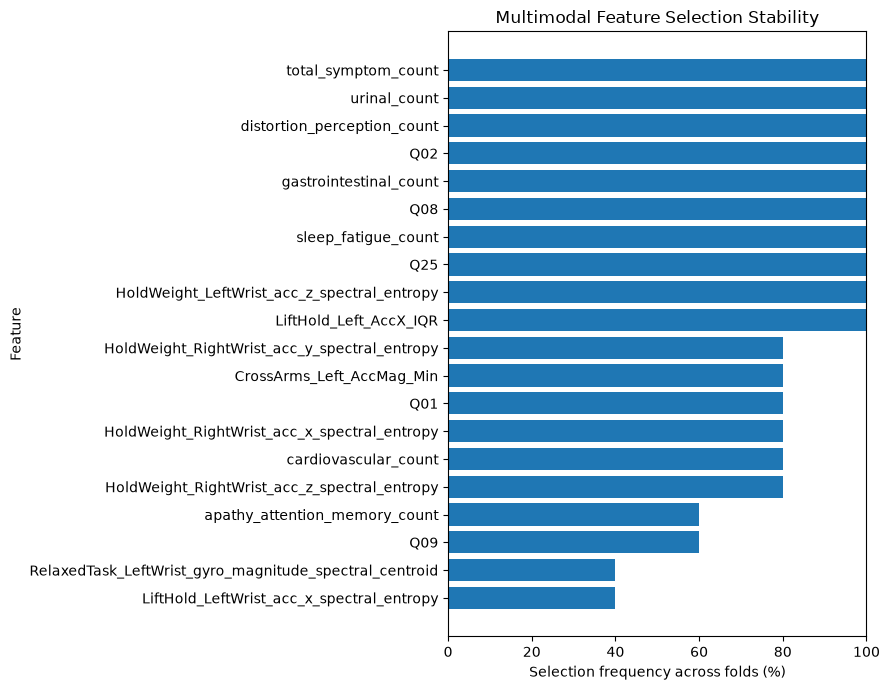

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures\multimodal_full_cv_feature_selection_stability.png


In [14]:
stable_features = (
    feature_selection_summary
    .head(20)
    .sort_values(
        [
            "times_selected",
            "mean_selection_score",
        ],
        ascending=[True, True],
    )
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    stable_features["feature"],
    stable_features["selection_percentage"],
)

ax.set_xlabel(
    "Selection frequency across folds (%)"
)
ax.set_ylabel("Feature")
ax.set_title(
    "Multimodal Feature Selection Stability"
)
ax.set_xlim(0, 100)

fig.tight_layout()

figure_path = (
    FIGURES_DIR
    / "multimodal_full_cv_feature_selection_stability.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {figure_path}")

## 15. Fold Macro F1

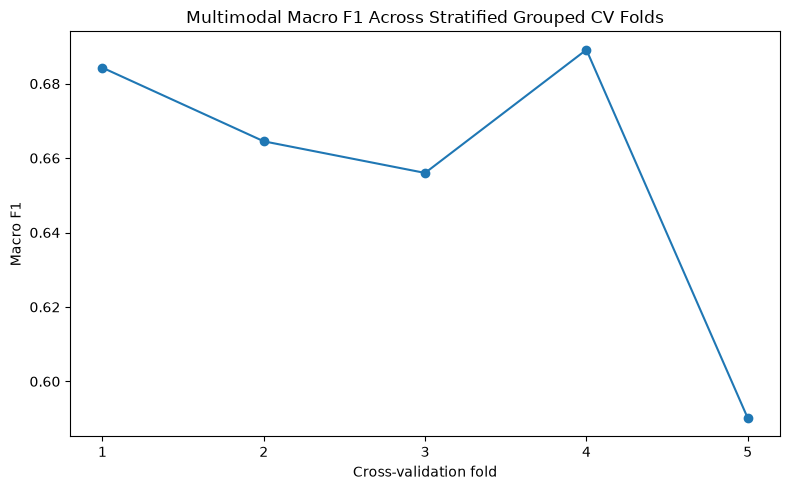

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures\multimodal_full_cv_fold_macro_f1.png


In [15]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    fold_performance["fold"],
    fold_performance["macro_f1"],
    marker="o",
)

ax.set_xlabel("Cross-validation fold")
ax.set_ylabel("Macro F1")
ax.set_title(
    "Multimodal Macro F1 Across Stratified Grouped CV Folds"
)
ax.set_xticks(range(1, N_SPLITS + 1))

fig.tight_layout()

figure_path = (
    FIGURES_DIR
    / "multimodal_full_cv_fold_macro_f1.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {figure_path}")

## 16. Out-of-fold confusion matrix

,Pred_0,Pred_1,Pred_2
True_0,63,8,8
True_1,28,188,60
True_2,19,26,69


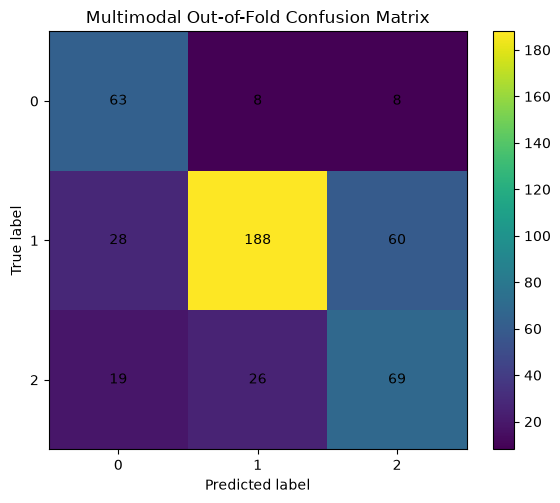

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures\multimodal_full_cv_out_of_fold_confusion_matrix.png


In [16]:
labels = sorted(
    oof_predictions["y_true"]
    .unique()
    .tolist()
)

cm = confusion_matrix(
    oof_predictions["y_true"],
    oof_predictions["y_pred"],
    labels=labels,
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"True_{label}"
        for label in labels
    ],
    columns=[
        f"Pred_{label}"
        for label in labels
    ],
)

display(cm_df)

cm_df.to_csv(
    METRICS_DIR
    / "multimodal_full_cv_out_of_fold_confusion_matrix.csv"
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(cm)
fig.colorbar(image, ax=ax)

ax.set_title(
    "Multimodal Out-of-Fold Confusion Matrix"
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

fig.tight_layout()

figure_path = (
    FIGURES_DIR
    / "multimodal_full_cv_out_of_fold_confusion_matrix.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {figure_path}")

## 17. Deliverables verification

In [17]:
deliverables = pd.DataFrame({
    "deliverable": [
        "StratifiedGroupKFold cross-validation pipeline",
        "Multimodal feature-selection workflow",
        "Selected feature lists for every fold",
        "Selected training feature datasets",
        "Selected validation feature datasets",
        "Feature-selection summary",
        "Fold-performance summary",
        "Validation-information verification",
        "Out-of-fold metrics",
        "Figures and confusion matrix",
    ],
    "status": ["READY"] * 10,
})

deliverables

,deliverable,status
0,StratifiedGroupKFold cross-validation pipeline,READY
1,Multimodal feature-selection workflow,READY
2,Selected feature lists for every fold,READY
3,Selected training feature datasets,READY
4,Selected validation feature datasets,READY
5,Feature-selection summary,READY
6,Fold-performance summary,READY
7,Validation-information verification,READY
8,Out-of-fold metrics,READY
9,Figures and confusion matrix,READY


## 18. Initial observations

In [18]:
best_fold = (
    fold_performance
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .iloc[0]
)

most_stable = (
    feature_selection_summary[
        feature_selection_summary[
            "times_selected"
        ]
        == N_SPLITS
    ]
    ["feature"]
    .tolist()
)

print("MULTIMODAL CROSS-VALIDATION SUMMARY")
print("-" * 50)

print(
    "Mean macro F1: "
    f"{fold_performance['macro_f1'].mean():.3f} "
    "± "
    f"{fold_performance['macro_f1'].std(ddof=1):.3f}"
)

print(
    "Mean balanced accuracy: "
    f"{fold_performance['balanced_accuracy'].mean():.3f} "
    "± "
    f"{fold_performance['balanced_accuracy'].std(ddof=1):.3f}"
)

print(
    f"Best fold by macro F1: "
    f"Fold {int(best_fold['fold'])} "
    f"({best_fold['macro_f1']:.3f})"
)

print(
    "Features selected in all five folds: "
    f"{len(most_stable)}"
)

if most_stable:
    print(most_stable)

print(
    "\nThe fold-specific selected features are used "
    "for stability analysis and should be re-fit "
    "during model tuning."
)

MULTIMODAL CROSS-VALIDATION SUMMARY
--------------------------------------------------
Mean macro F1: 0.657 ± 0.040
Mean balanced accuracy: 0.695 ± 0.039
Best fold by macro F1: Fold 4 (0.689)
Features selected in all five folds: 10
['total_symptom_count', 'urinal_count', 'distortion_perception_count', 'Q02', 'gastrointestinal_count', 'Q08', 'sleep_fatigue_count', 'Q25', 'HoldWeight_LeftWrist_acc_z_spectral_entropy', 'LiftHold_Left_AccX_IQR']

The fold-specific selected features are used for stability analysis and should be re-fit during model tuning.


## 19. Conclusion

This notebook applies five-fold `StratifiedGroupKFold` cross-validation and fold-specific feature selection to the **full multimodal dataset**, which combines demographic, questionnaire, and wearable features at the participant level.

For every fold, preprocessing parameters, zero-variance filtering, ANOVA feature scores, and the selected feature set are learned using the training fold only. `patient_id` is supplied as the grouping variable to explicitly enforce participant-level separation.

Twenty features are retained as an initial fixed value to support consistent stability analysis. This value should be optimized during subsequent hyperparameter tuning. The selected feature sets generated here are intended primarily for stability analysis rather than direct reuse as a fixed tuning feature set; feature selection should be re-fit inside the later tuning pipeline.

The generated fold-specific feature datasets, feature-selection summary, performance summary, out-of-fold metrics, and figures provide the required outputs for downstream multimodal model optimization.